In [1]:
from itertools import product, permutations
from collections import defaultdict
import pandas as pd
import plotly.graph_objects as go

In [2]:
# Define the range of numbers and the list of operators
nums = list(range(1, 13))
ops = ['+', '-', '*', '/']

def evaluate_expression(expression):
    try:
        return eval(expression) == 24
    except ZeroDivisionError:
        return False

valid = set()
counts = defaultdict(list)
i = 0
# Generate all permutations of 4 numbers
for num_perm in product(nums, repeat=4) :
    num1, num2, num3, num4 = num_perm
    # Generate all combinations of 3 operators (with repetition allowed)
    for op_comb in product(ops, repeat=3):
        op1, op2, op3 = op_comb
        # Different ways to parenthesize expressions
        expressions = [
            f"({num1} {op1} {num2}) {op2} ({num3} {op3} {num4})",
            f"(({num1} {op1} {num2}) {op2} {num3}) {op3} {num4}",
            f"({num1} {op1} ({num2} {op2} {num3})) {op3} {num4}",
            f"{num1} {op1} (({num2} {op2} {num3}) {op3} {num4})",
            f"{num1} {op1} ({num2} {op2} ({num3} {op3} {num4}))"
        ]
        # Evaluate each expression
        for expr in expressions:
            i += 1
            if evaluate_expression(expr):
                valid.add(expr)
                counts[','.join([str(x) for x in sorted(num_perm)])].append(expr)

In [3]:
number = {nums:len(e) for nums,e in counts.items()}

In [4]:
df = pd.DataFrame(number,index=['count']).T

In [5]:
df = df.reset_index().rename(columns={'index':'numbers'})

In [6]:
df = df.sort_values(by = ['count'],ascending=False)

In [7]:
fig = go.Figure()


fig.add_trace(
    go.Bar(
        x = df['numbers'],
        y = df['count'].head(50)
    )
)


fig.update_layout(
    title = 'Count of Valid Expression by Number Selections',
    template = 'plotly_white',
    yaxis_title = 'Count',
    xaxis_title = 'Numbers'
)

fig.show()

counts

In [8]:
counts['1,4,8,12']

['(1 * 4) + (8 + 12)',
 '((1 * 4) + 8) + 12',
 '(1 * (4 + 8)) + 12',
 '1 * ((4 + 8) + 12)',
 '1 * (4 + (8 + 12))',
 '(1 / 4) * (8 * 12)',
 '((1 / 4) * 8) * 12',
 '(1 / (4 / 8)) * 12',
 '1 / (4 / (8 * 12))',
 '1 / ((4 / 8) / 12)',
 '(1 * 4) + (12 + 8)',
 '((1 * 4) + 12) + 8',
 '(1 * (4 + 12)) + 8',
 '1 * ((4 + 12) + 8)',
 '1 * (4 + (12 + 8))',
 '(1 / 4) * (12 * 8)',
 '((1 / 4) * 12) * 8',
 '(1 / (4 / 12)) * 8',
 '1 / (4 / (12 * 8))',
 '1 / ((4 / 12) / 8)',
 '((1 + 8) * 4) - 12',
 '(1 * 8) + (4 + 12)',
 '((1 * 8) + 4) + 12',
 '(1 * (8 + 4)) + 12',
 '1 * ((8 + 4) + 12)',
 '1 * (8 + (4 + 12))',
 '((1 * 8) / 4) * 12',
 '(1 * (8 / 4)) * 12',
 '1 * ((8 / 4) * 12)',
 '(1 * 8) / (4 / 12)',
 '1 * (8 / (4 / 12))',
 '(1 * 8) + (12 + 4)',
 '((1 * 8) + 12) + 4',
 '(1 * (8 + 12)) + 4',
 '1 * ((8 + 12) + 4)',
 '1 * (8 + (12 + 4))',
 '(1 * 8) * (12 / 4)',
 '((1 * 8) * 12) / 4',
 '(1 * (8 * 12)) / 4',
 '1 * ((8 * 12) / 4)',
 '1 * (8 * (12 / 4))',
 '(1 * 12) + (4 + 8)',
 '((1 * 12) + 4) + 8',
 '(1 * (12 

In [9]:
df.iloc[-1]

numbers    5,5,8,8
count            1
Name: 825, dtype: object

In [10]:
fig = go.Figure()


fig.add_trace(
    go.Histogram(
       x = df['count'],
       nbinsx=100
    ),

)


fig.update_layout(
    title = 'Distribution of Number of Valid Expressions',
    template = 'plotly_white',
    yaxis_title = 'Count',
    xaxis_title = 'Number of Valid Expressions'
)

fig.show()

In [11]:
(12**4)*(4**3)*5

6635520

In [12]:
len(valid) / ((12**4)*(4**3)*5)

0.006302143614969136

In [17]:
import numpy as np
np.median(list(number.values()))

np.float64(22.0)

In [26]:
df = pd.DataFrame(list(number.items()), columns=['Combination', 'SolutionCount'])

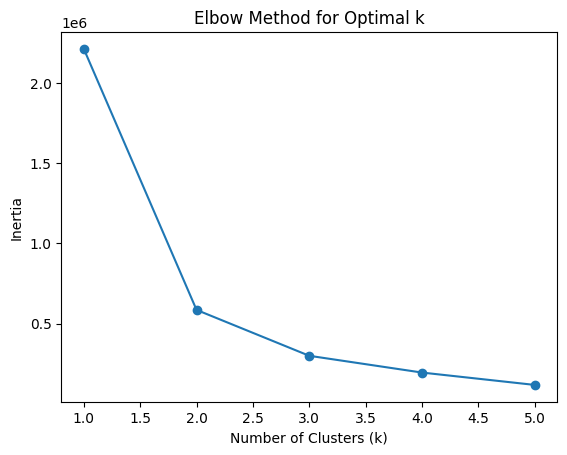

In [29]:
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reshape data for K-Means (needs 2D input)
X = np.array(df['SolutionCount']).reshape(-1, 1)

# Find optimal k using the Elbow Method
inertia = []
for k in range(1, 6):
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 6), inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

In [31]:
kmeans = KMeans(n_clusters=3, random_state=42).fit(X)
df['cluster'] = kmeans.labels_
print(df.groupby('cluster')['SolutionCount'].describe())

         count        mean        std    min    25%    50%    75%    max
cluster                                                                 
0        814.0   17.987715  12.698601    1.0    8.0   16.0   26.0   49.0
1        171.0   80.070175  20.378933   50.0   64.0   76.0   94.0  121.0
2         83.0  162.457831  34.422519  122.0  139.0  152.0  182.0  335.0


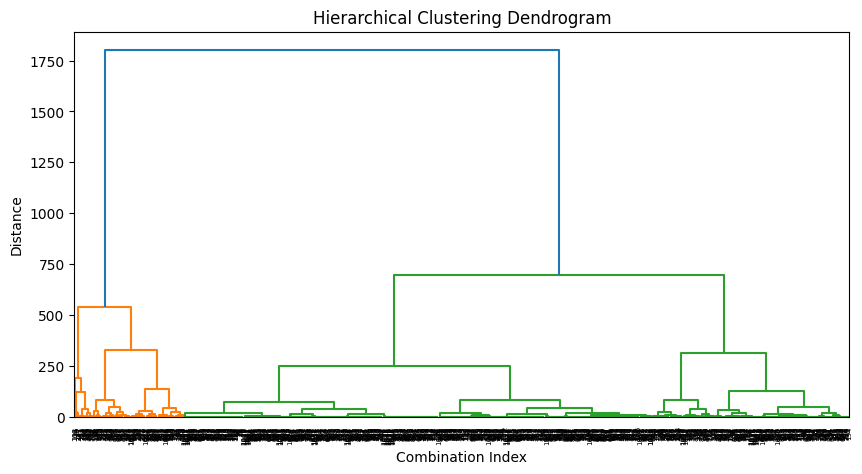

In [32]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X, method='ward')
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.xlabel('Combination Index')
plt.ylabel('Distance')
plt.title('Hierarchical Clustering Dendrogram')
plt.show()

In [20]:
easy = 0 
medium = 0
hard = 0

threshold = 20

for solution,count in number.items():
    if count < threshold:
        easy += 1
    elif count < 3*threshold:
        medium += 1
    else:
        hard += 1
print(easy,medium,hard)

471 366 231
